In [1]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

n_students = 3000

# Attributes used for the UI
student_names = [f"Student_{i}" for i in range(1, n_students + 1)]
student_ids = np.arange(1001, 1001 + n_students)

#  Input Features
attendance = np.round(np.random.normal(85, 10, n_students).clip(0, 100), 1)
prev_exam = np.round(np.random.normal(75, 12, n_students).clip(0, 100), 1)
prev_sem = np.round(np.random.normal(75, 12, n_students).clip(0, 100), 1)
assignments = np.round(np.random.normal(80, 10, n_students).clip(0, 100), 1)
internal = np.round(np.random.normal(78, 10, n_students).clip(0, 100), 1)
study_hours = np.round(np.random.normal(4, 1.5, n_students).clip(0, 14), 1)
participation = np.round(np.random.normal(70, 15, n_students).clip(0, 100), 1)
sleep = np.round(np.random.normal(7, 1.5, n_students).clip(4, 10), 1)

# Target Variable Calculation

final_scores = np.round((
    (attendance * 0.15) +
    (prev_exam * 0.25) +
    (prev_sem * 0.25) +
    (assignments * 0.10) +
    (internal * 0.10) +
    (study_hours * 1.0) +
    (participation * 0.05) +
    (sleep * 0.5) +
    np.random.normal(0, 0.05, n_students) # Microscopic noise
).clip(0, 100), 1)

#  DataFrame creation
df = pd.DataFrame({
    'Student Name': student_names,
    'Student ID': student_ids,
    'Attendance Percentage': attendance,
    'Previous Exam Score': prev_exam,
    'Previous Semester Score': prev_sem,
    'Assignment Score': assignments,
    'Internal Assessment Score': internal,
    'Study Hours per Day': study_hours,
    'Class Participation Percentage': participation,
    'Sleep Hours per Day': sleep,
    'Final Exam Score': final_scores
})

df.head()

,Student Name,Student ID,Attendance Percentage,Previous Exam Score,Previous Semester Score,Assignment Score,Internal Assessment Score,Study Hours per Day,Class Participation Percentage,Sleep Hours per Day,Final Exam Score
0,Student_1,1001,90.0,52.1,61.6,87.7,89.7,3.8,74.8,10.0,72.2
1,Student_2,1002,83.6,64.7,67.4,90.7,59.2,4.0,58.3,7.0,70.9
2,Student_3,1003,91.5,70.0,63.7,85.0,74.7,4.1,80.4,6.5,74.6
3,Student_4,1004,100.0,97.7,68.4,60.6,77.6,5.4,61.1,6.2,82.0
4,Student_5,1005,82.7,81.7,72.4,78.4,78.2,2.9,81.2,7.6,77.3


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Select features and the target
X = df.drop(columns=['Student Name', 'Student ID', 'Final Exam Score'])
y = df['Final Exam Score']

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the model
model = RandomForestRegressor(n_estimators=200, random_state=42)

#  Training
model.fit(X_train, y_train)

# Evaluation
predictions = model.predict(X_test)
model_accuracy = r2_score(y_test, predictions)

print("Model Training Complete!")
print(f"R2 Score: {model_accuracy * 100:.2f}%")

Model Training Complete!
R2 Score: 91.55%


In [25]:
df.to_csv("student_data.csv", index=False)
print("data is successfully saved to the csv ")

data is successfully saved to the csv 


/tmp/ipykernel_1829/4081662965.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


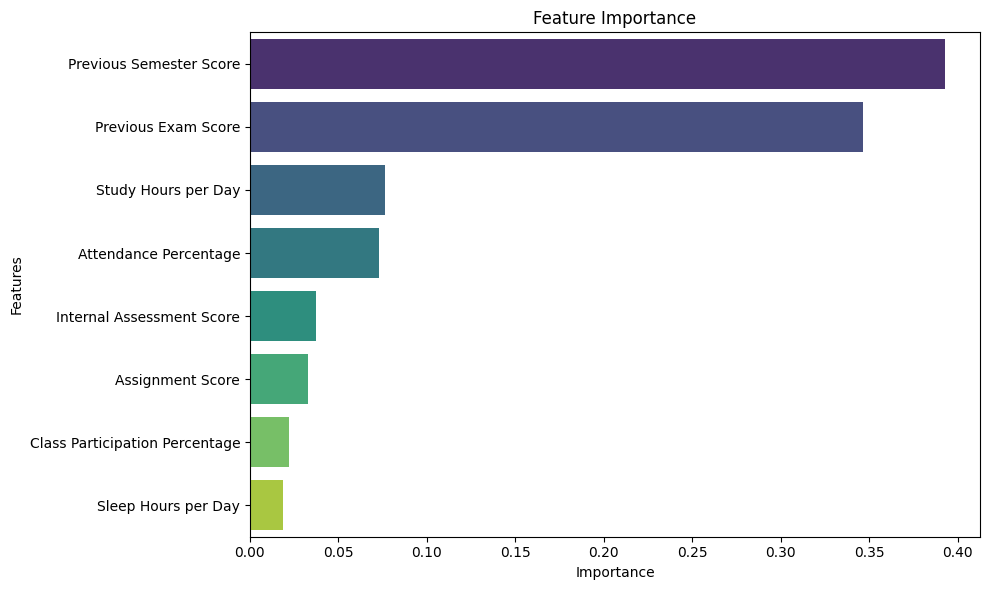

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [12]:
import joblib
joblib.dump(model, 'student_performance_model.pkl')
loaded_model = joblib.load('student_performance_model.pkl')

print("Success! The model is saved as 'student_performance_model.pkl'")

Success! The model is saved as 'student_performance_model.pkl'


In [15]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(page_title="Student Predictor", page_icon="🎓", layout="wide")

@st.cache_resource
def load_model():
    return joblib.load("student_performance_model.pkl")

model = load_model()

with st.sidebar:
    st.title("Project")
    st.write("Student performance prediction using Random Forest.")
    st.divider()
    st.write("Developer: Amit Sharma")
    st.write("Course: B.Tech CSE - Data Science")
    st.write("College: Greater Noida Institute of Technology")

st.title("Student Performance Predictor")
st.write("Enter the details below.")
st.divider()

st.subheader("Student Details")

col1, col2, col3 = st.columns(3)

with col1:
    attendance = st.number_input("Attendance (%)", 0.0, 100.0, 85.0)
    prev_exam = st.number_input("Previous Exam", 0.0, 100.0, 75.0)
    prev_sem = st.number_input("Previous Semester", 0.0, 100.0, 75.0)

with col2:
    assignments = st.number_input("Assignment", 0.0, 100.0, 80.0)
    internal = st.number_input("Internal Assessment", 0.0, 100.0, 78.0)
    study_hours = st.number_input("Study Hours", 0.0, 14.0, 4.0)

with col3:
    participation = st.number_input("Participation (%)", 0.0, 100.0, 70.0)
    sleep = st.number_input("Sleep Hours", 4.0, 10.0, 7.0)
    st.write("")
    predict = st.button("Predict")

if predict:
    data = pd.DataFrame({
        "Attendance Percentage": [attendance],
        "Previous Exam Score": [prev_exam],
        "Previous Semester Score": [prev_sem],
        "Assignment Score": [assignments],
        "Internal Assessment Score": [internal],
        "Study Hours per Day": [study_hours],
        "Class Participation Percentage": [participation],
        "Sleep Hours per Day": [sleep]
    })

    prediction = model.predict(data)[0]

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Result")
        st.metric("Final Score", f"{prediction:.1f} / 100")

        if prediction >= 85:
            st.success("Excellent")
        elif prediction >= 70:
            st.info("Good")
        else:
            st.warning("Needs Improvement")

    with col2:
        st.subheader("Feature Importance")

        importance = pd.DataFrame({
            "Feature": data.columns,
            "Importance": model.feature_importances_
        }).sort_values("Importance", ascending=True)

        st.bar_chart(importance.set_index("Feature"))

Overwriting app.py


In [16]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 84.4 MB/s eta 0:00:00


In [21]:
# Download and install Cloudflare Tunnel
!wget -q -O cloudflared.deb https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared.deb

# Run the Streamlit app in the background
!streamlit run app.py &>/content/logs.txt &

# Create the Cloudflare link
!cloudflared tunnel --url http://localhost:8501

(Reading database ... 118336 files and directories currently installed.)
Preparing to unpack cloudflared.deb ...
Unpacking cloudflared (2026.8.2) over (2026.8.1) ...
Setting up cloudflared (2026.8.2) ...
Processing triggers for man-db (2.10.2-1) ...
2026-08-14T12:27:41Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-14T12:27:41Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-14T12:27:46Z INF +---------------------------------------------

In [19]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
numpy
joblib


Writing requirements.txt
